In [1]:
# Install Java 11
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid

In [2]:
# Install Spark
!wget -q https://archive.apache.org/dist/spark/spark-3.5.3/spark-3.5.3-bin-hadoop3.tgz
!tar xf spark-3.5.3-bin-hadoop3.tgz

In [3]:
# Install findspark
!pip install -q findspark

In [4]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.3-bin-hadoop3"

In [5]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

## Question 2

In [6]:
strings = spark.read.text("/content/assignment_4.txt")
strings.show(20, truncate=False)

+--------------------------------------------------------------------------------------------------------------+
|value                                                                                                         |
+--------------------------------------------------------------------------------------------------------------+
|                                                                                                              |
|TensorFlow is an open-source machine learning and deep learning framework originally developed by Google.     |
|It is designed to support the development, training, and deployment of machine learning models at scale.      |
|TensorFlow is widely used in research, industry, and education due to its flexibility and performance.        |
|                                                                                                              |
|At the core of TensorFlow is the concept of a tensor. A tensor is a multi-dimensional array use

In [7]:
strings.count()

37

In [9]:
from pyspark.sql.functions import col, lower

filtered = strings.filter(lower(col("value")).contains("tensor"))
filtered.count()

23

## Question 3

In [10]:
df = (spark.read.format("csv")
      .option("header", "true")
      .option("inferSchema", "true")
      .load("/content/cancer_dataset_uae.csv"))


In [11]:
df.columns

['Patient_ID',
 'Age',
 'Gender',
 'Nationality',
 'Emirate',
 'Diagnosis_Date',
 'Cancer_Type',
 'Cancer_Stage',
 'Treatment_Type',
 'Treatment_Start_Date',
 'Hospital',
 'Primary_Physician',
 'Outcome',
 'Death_Date',
 'Cause_of_Death',
 'Smoking_Status',
 'Comorbidities',
 'Ethnicity',
 'Weight',
 'Height']

In [13]:
df.show()

+----------+---+------+-----------+--------------+--------------+-----------+------------+--------------+--------------------+--------------------+-----------------+---------------+-------------------+--------------+--------------+--------------------+-----------+------+------+
|Patient_ID|Age|Gender|Nationality|       Emirate|Diagnosis_Date|Cancer_Type|Cancer_Stage|Treatment_Type|Treatment_Start_Date|            Hospital|Primary_Physician|        Outcome|         Death_Date|Cause_of_Death|Smoking_Status|       Comorbidities|  Ethnicity|Weight|Height|
+----------+---+------+-----------+--------------+--------------+-----------+------------+--------------+--------------------+--------------------+-----------------+---------------+-------------------+--------------+--------------+--------------------+-----------+------+------+
| PAT000001| 69|Female|    Emirati| Umm Al Quwain|    2020-11-30|      Liver|          II|     Radiation|          2020-12-04|Sheikh Khalifa Ho...|         Dr. VO4

In [14]:
from pyspark.sql.functions import count

grouped_df = (df.select("Cancer_Type", "Outcome")
              .groupBy("Cancer_Type", "Outcome")
              .agg(count("*").alias("Total_Patients"))
              .orderBy("Total_Patients", ascending=False))

grouped_df.show(truncate=False)

+-----------+---------------+--------------+
|Cancer_Type|Outcome        |Total_Patients|
+-----------+---------------+--------------+
|Leukemia   |Recovered      |660           |
|Liver      |Recovered      |630           |
|Colorectal |Recovered      |618           |
|Lung       |Recovered      |615           |
|Breast     |Recovered      |614           |
|Ovarian    |Recovered      |601           |
|Prostate   |Recovered      |599           |
|Pancreatic |Recovered      |594           |
|Ovarian    |Under Treatment|530           |
|Leukemia   |Under Treatment|527           |
|Liver      |Under Treatment|518           |
|Breast     |Under Treatment|507           |
|Prostate   |Under Treatment|506           |
|Pancreatic |Under Treatment|504           |
|Colorectal |Under Treatment|499           |
|Lung       |Under Treatment|486           |
|Pancreatic |Deceased       |145           |
|Lung       |Deceased       |132           |
|Ovarian    |Deceased       |128           |
|Leukemia 

In [15]:
abu_dhabi_df = (df.filter(df.Emirate == "Abu Dhabi")
                .groupBy("Treatment_Type")
                .agg(count("*").alias("Patients_Treated"))
                .orderBy("Patients_Treated", ascending=False))

abu_dhabi_df.show(5, truncate=False)

+--------------+----------------+
|Treatment_Type|Patients_Treated|
+--------------+----------------+
|Surgery       |379             |
|Radiation     |373             |
|Chemotherapy  |364             |
|Immunotherapy |355             |
+--------------+----------------+



In [16]:
smoking_outcome_df = (df.select("Smoking_Status", "Outcome")
                      .groupBy("Smoking_Status", "Outcome")
                      .agg(count("*").alias("Total_Patients"))
                      .orderBy("Smoking_Status", "Total_Patients", ascending=False))

In [17]:
smoking_outcome_df.show(truncate=False)

+--------------+---------------+--------------+
|Smoking_Status|Outcome        |Total_Patients|
+--------------+---------------+--------------+
|Smoker        |Recovered      |1487          |
|Smoker        |Under Treatment|1253          |
|Smoker        |Deceased       |305           |
|Non-Smoker    |Recovered      |2515          |
|Non-Smoker    |Under Treatment|2031          |
|Non-Smoker    |Deceased       |492           |
|Former Smoker |Recovered      |929           |
|Former Smoker |Under Treatment|793           |
|Former Smoker |Deceased       |195           |
+--------------+---------------+--------------+



<Figure size 640x480 with 0 Axes>

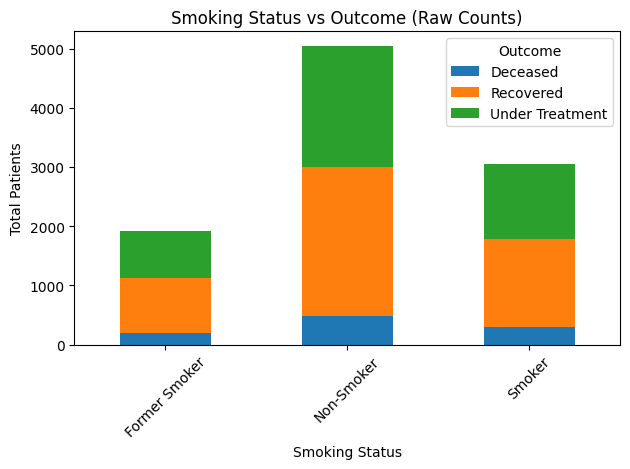

<Figure size 640x480 with 0 Axes>

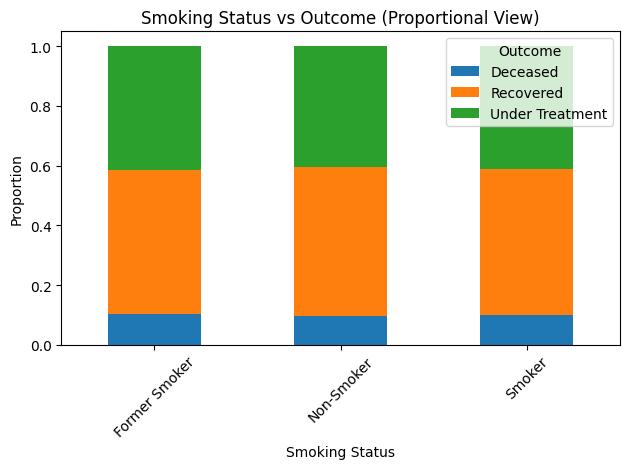

In [18]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
pdf = smoking_outcome_df.toPandas()

# Pivot to get Outcome counts per Smoking_Status
pivot_df = pdf.pivot(
    index="Smoking_Status",
    columns="Outcome",
    values="Total_Patients"
).fillna(0)

# --- Raw Count Visualization ---
plt.figure()
pivot_df.plot(kind="bar", stacked=True)
plt.xlabel("Smoking Status")
plt.ylabel("Total Patients")
plt.title("Smoking Status vs Outcome (Raw Counts)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Proportional Visualization ---
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0)

plt.figure()
pivot_pct.plot(kind="bar", stacked=True)
plt.xlabel("Smoking Status")
plt.ylabel("Proportion")
plt.title("Smoking Status vs Outcome (Proportional View)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
